# Aquaculture Industry Analysis in Australia

This notebook explores production trends, industry concentration, and volatility across major Australian aquaculture species.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
file_path = "../data/Fisheries Aquaculture Statistics 2024-25 v1.0.xlsx"

df_raw = pd.read_excel(file_path, sheet_name="Table 4", header=None)
df_raw.head(15)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STATISTICS
6,NaN,"4 Aquaculture production, Australia",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Commodity a,unit,1998–99,1999–00,2000–01,2001–02,2002–03,2003–04,2004–05,...,2015–16,2016–17,2017–18,2018–19,2019–20,2020–21,2021–22,2022–23,2023–24,2024–25p
8,NaN,Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Finfish,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def find_header_row(df_raw):
    for i in range(len(df_raw)):
        row_vals = df_raw.iloc[i].astype(str).str.strip().tolist()
        if any("Commodity" in v for v in row_vals) and any("unit" in v.lower() for v in row_vals):
            return i
    return None

header_row = find_header_row(df_raw)
print("header_row:", header_row)

header_row: 7


In [4]:
df = df_raw.iloc[header_row:].copy()
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df.columns = [str(c).strip() for c in df.columns]
df = df.drop(columns=df.columns[0])

df.head(10)

,Commodity a,unit,1998–99,1999–00,2000–01,2001–02,2002–03,2003–04,2004–05,2005–06,...,2015–16,2016–17,2017–18,2018–19,2019–20,2020–21,2021–22,2022–23,2023–24,2024–25p
0,Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Finfish,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Salmonids b,$’000,82437,97844,112085,124949,118101,140388,146922,231452,...,717714,756068,854768,839334,904080,1031434,1149408,1376516,1294977,na
3,Tunas,$’000,166700,202000,263793,260500,267342,243217,139955,155795,...,126870,115000,126000,129000,137000,91000,110400,120000,76970,na
4,Silver Perch,$’000,1831,2540,2554,2787,3148,2772,2948,3541,...,4601,3982,4201,2544,2331,2456,2046,1646,1620,na
5,Barramundi,$’000,7819,8380,8445,9922,16079,13433,15545,18801,...,34979,41076,53606,66083,78963,86239,60572,111012,113815,na
6,Other Finfish c,$’000,7062,7236,9731,9964,17934,16405,6347,3466,...,78142,7309,48051,55488,54906,69600,68281,89032,93835,na
7,Total,$’000,265848,317999,396609,408122,422604,416214,311716,413055,...,962306,923435,1086626,1092448,1177280,1280729,1390706,1698206,1581218,na
8,Crustaceans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Prawns,$’000,42156,51268,49534,65440,56068,57762,50364,49727,...,86485,85669,80521,83775,134492,159701,180821,217499,211661,na


In [5]:
df = df.rename(columns={"Commodity a": "commodity"})

# 1. 切出 Value 區塊
value_start_idx = df[
    df["commodity"].astype(str).str.strip().str.fullmatch("Value", case=False, na=False)
].index[0]

quantity_start_idx = df[
    df["commodity"].astype(str).str.strip().str.fullmatch("Quantity", case=False, na=False)
].index[0]

df_value = df.loc[value_start_idx + 1 : quantity_start_idx - 1].copy()

# 2. 排除分類列與總計列
exclude_exact = ["Finfish", "Crustaceans", "Molluscs", "Total", "Total value"]

df_value = df_value[
    ~df_value["commodity"].astype(str).str.strip().isin(exclude_exact)
].copy()

# 3. 清理 commodity 註腳
df_value["commodity"] = (
    df_value["commodity"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+[a-zA-Z]$", "", regex=True)
)

# 4. wide -> long
year_cols = [c for c in df_value.columns if c not in ["commodity", "unit"]]

df_aqua_aus = df_value.melt(
    id_vars=["commodity", "unit"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

# 5. 清理 value
df_aqua_aus["value"] = (
    df_aqua_aus["value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
    .replace({
        "-": pd.NA,
        "na": pd.NA,
        "nan": pd.NA,
        "": pd.NA
    })
)

df_aqua_aus["value"] = pd.to_numeric(df_aqua_aus["value"], errors="coerce")
df_aqua_aus["year"] = df_aqua_aus["year"].astype(str).str.strip()
df_aqua_aus["commodity"] = df_aqua_aus["commodity"].astype(str).str.strip()

# 6. 主分析版本
exclude_contains = ["Other", "nei"]

df_aqua_main = df_aqua_aus[
    ~df_aqua_aus["commodity"].str.contains("|".join(exclude_contains), case=False, na=False)
].copy()

df_aqua_main = df_aqua_main[
    ~df_aqua_main["year"].str.contains("p", case=False, na=False)
].copy()

print(sorted(df_aqua_main["commodity"].dropna().unique()))
df_aqua_main.head()

['Abalone', 'Barramundi', 'Blue Mussel', 'Marron', 'Oysters', 'Pearls', 'Prawns', 'Redclaw', 'Salmonids', 'Silver Perch', 'Tunas', 'Yabbies']


,commodity,unit,year,value
0,Salmonids,$’000,1998–99,82437.0
1,Tunas,$’000,1998–99,166700.0
2,Silver Perch,$’000,1998–99,1831.0
3,Barramundi,$’000,1998–99,7819.0
5,Prawns,$’000,1998–99,42156.0


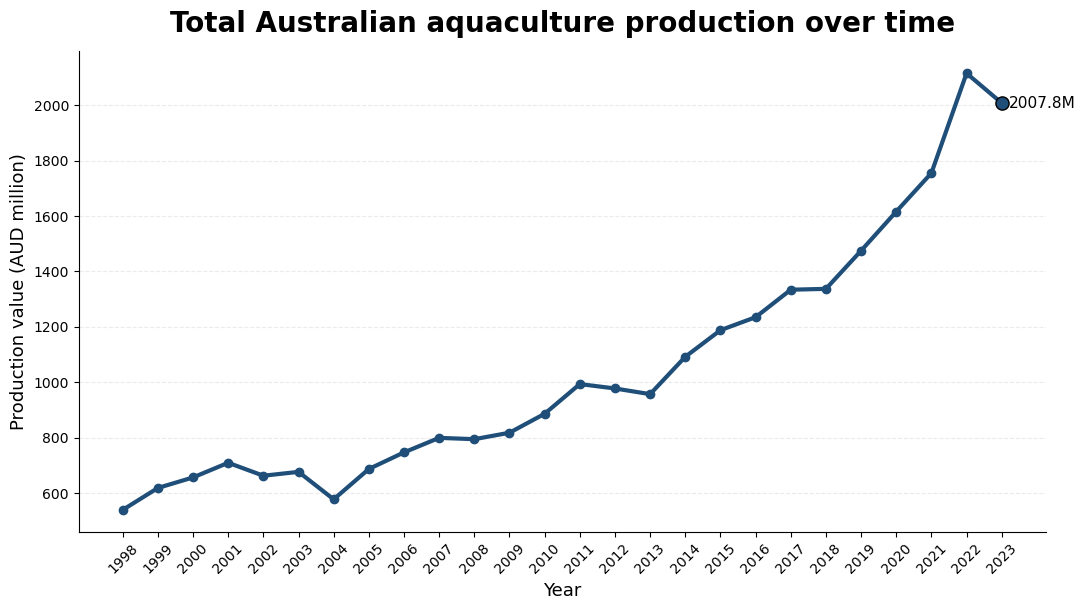

In [6]:
def plot_total_production_trend(df):
    plot_df = df.copy()

    plot_df["year_start"] = plot_df["year"].astype(str).str.extract(r"(\d{4})")[0]
    plot_df["year_start"] = pd.to_numeric(plot_df["year_start"], errors="coerce")
    plot_df = plot_df.dropna(subset=["year_start", "value", "commodity"]).copy()

    total_by_year = (
        plot_df.groupby("year_start", as_index=False)["value"]
        .sum()
        .sort_values("year_start")
    )

    # 轉成 million
    total_by_year["value_million"] = total_by_year["value"] / 1000

    fig, ax = plt.subplots(figsize=(11, 6.2))

    ax.plot(
        total_by_year["year_start"],
        total_by_year["value_million"],
        color="#1F4E79",
        linewidth=3,
        marker="o",
        markersize=6
    )

    # 強調最後一個點
    last_row = total_by_year.iloc[-1]
    ax.scatter(
        last_row["year_start"],
        last_row["value_million"],
        s=90,
        color="#1F4E79",
        edgecolor="black",
        zorder=5
    )

    ax.text(
        last_row["year_start"] + 0.2,
        last_row["value_million"],
        f'{last_row["value_million"]:.1f}M',
        fontsize=11,
        va="center"
    )

    ax.set_title(
        "Total Australian aquaculture production over time",
        fontsize=20,
        fontweight="bold",
        pad=14
    )

    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("Production value (AUD million)", fontsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.grid(axis="x", visible=False)

    plt.xticks(total_by_year["year_start"], rotation=45)
    plt.tight_layout()
    plt.savefig("../figures/total_production_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_total_production_trend(df_aqua_main)

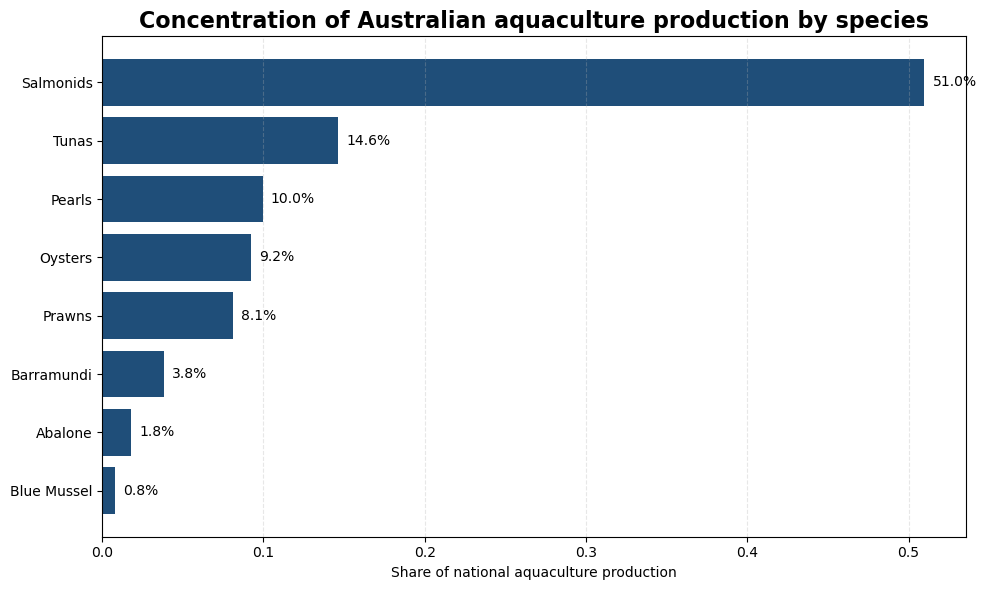

In [7]:
def plot_species_concentration(df, top_n=8):

    species_total = (
        df.groupby("commodity")["value"]
        .sum()
        .sort_values(ascending=False)
    )

    share = species_total / species_total.sum()

    top_species = share.head(top_n)

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.barh(
        top_species.index[::-1],
        top_species.values[::-1],
        color="#1F4E79"
    )

    # add labels
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{width*100:.1f}%",
            va="center",
            fontsize=10
        )

    ax.set_xlabel("Share of national aquaculture production")
    ax.set_title(
        "Concentration of Australian aquaculture production by species",
        fontsize=16,
        fontweight="bold"
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig("../figures/species_concentration.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_species_concentration(df_aqua_main)

In [8]:
volatility = (
    df_aqua_main.groupby("commodity")["value"]
    .agg(["mean", "std"])
)

volatility["cv"] = volatility["std"] / volatility["mean"]
volatility = volatility.sort_values("cv", ascending=False)

top_species = (
    df_aqua_main.groupby("commodity")["value"]
    .sum()
    .sort_values(ascending=False)
)

major_species = top_species.head(8).index

volatility_major = volatility.loc[major_species] \
    .sort_values("cv", ascending=True)

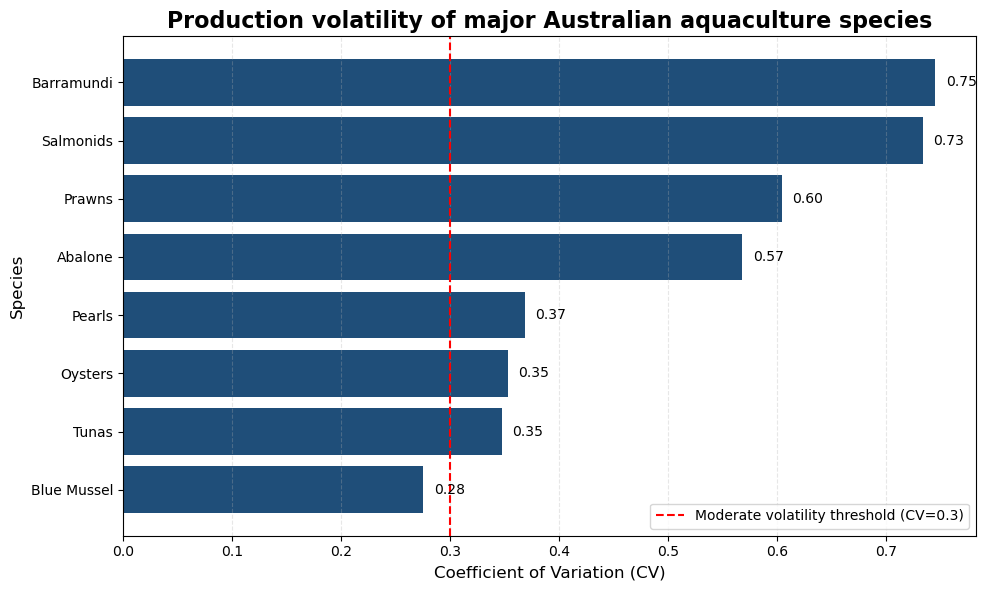

In [9]:
def plot_species_volatility(volatility_df):

    volatility_df = volatility_df.sort_values("cv", ascending=True)

    fig, ax = plt.subplots(figsize=(10,6))

    bars = ax.barh(
        volatility_df.index,
        volatility_df["cv"],
        color="#1F4E79"
    )

    # reference line
    ax.axvline(
        0.3,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Moderate volatility threshold (CV=0.3)"
    )

    # label CV values
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            fontsize=10
        )

    ax.set_xlabel("Coefficient of Variation (CV)", fontsize=12)
    ax.set_ylabel("Species", fontsize=12)

    ax.set_title(
        "Production volatility of major Australian aquaculture species",
        fontsize=16,
        fontweight="bold"
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig("../figures/species_volatility.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_species_volatility(volatility_major)

In [10]:
species_total = (
    df_aqua_main.groupby("commodity")["value"]
    .sum()
    .sort_values(ascending=False)
)

share = species_total / species_total.sum()

share.head()

commodity
Salmonids    0.509878
Tunas        0.146248
Pearls       0.099532
Oysters      0.092249
Prawns       0.081146
Name: value, dtype: float64

In [11]:
share.head(3).sum()

np.float64(0.7556587148167957)

In [12]:
plot_df = df_aqua_main.copy()

# 從 "1998–99" 這種格式抓出前四碼
plot_df["year_start"] = plot_df["year"].astype(str).str.extract(r"(\d{4})")[0]
plot_df["year_start"] = pd.to_numeric(plot_df["year_start"], errors="coerce")

# 移除缺值
plot_df = plot_df.dropna(subset=["year_start", "value", "commodity"]).copy()

print(plot_df.shape)
print(plot_df[["year", "year_start"]].head())

(312, 5)
      year  year_start
0  1998–99        1998
1  1998–99        1998
2  1998–99        1998
3  1998–99        1998
5  1998–99        1998


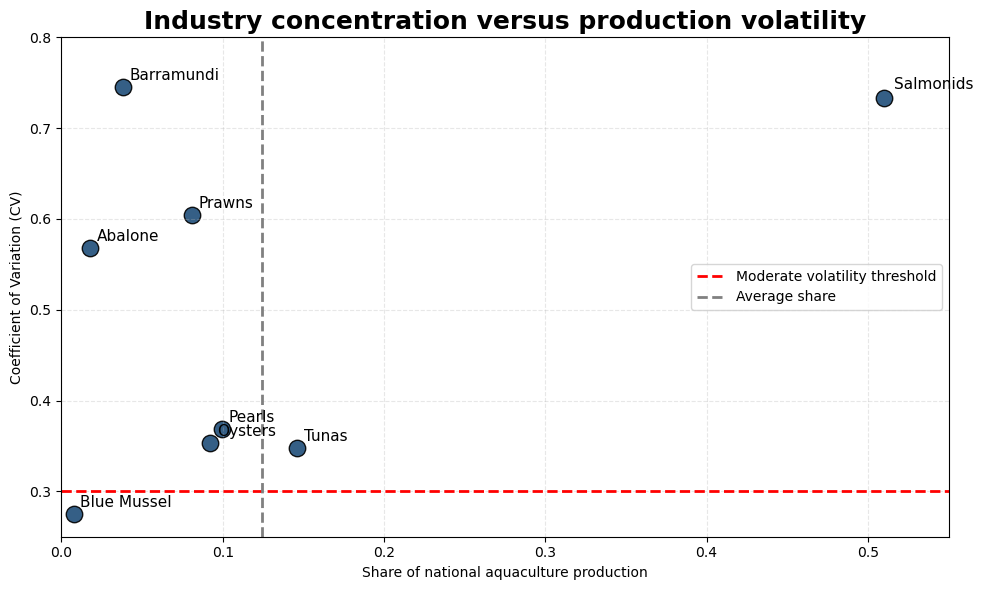

In [13]:
def plot_share_vs_volatility(df, share_threshold=0.005):

    plot_df = df.copy()

    species_stats = (
        plot_df.groupby("commodity")["value"]
        .agg(["sum", "mean", "std"])
        .reset_index()
    )

    species_stats["cv"] = species_stats["std"] / species_stats["mean"]
    species_stats["share"] = species_stats["sum"] / species_stats["sum"].sum()

    species_stats_main = species_stats[species_stats["share"] >= share_threshold].copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        species_stats_main["share"],
        species_stats_main["cv"],
        color="#1F4E79",
        s=140,
        edgecolor="black",
        alpha=0.9
    )

    # 調整文字位置
    for _, row in species_stats_main.iterrows():

        offset_x = 0.004
        offset_y = 0.008

        if row["commodity"] == "Salmonids":
            offset_x = 0.006
            offset_y = 0.01

        ax.text(
            row["share"] + offset_x,
            row["cv"] + offset_y,
            row["commodity"],
            fontsize=11
        )

    # reference lines
    ax.axhline(
        0.3,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Moderate volatility threshold"
    )

    ax.axvline(
        species_stats_main["share"].mean(),
        color="grey",
        linestyle="--",
        linewidth=2,
        label="Average share"
    )

    ax.set_title(
        "Industry concentration versus production volatility",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("Share of national aquaculture production")
    ax.set_ylabel("Coefficient of Variation (CV)")

    ax.grid(True, linestyle="--", alpha=0.3)

    ax.set_xlim(0, 0.55)
    ax.set_ylim(0.25, 0.8)

    ax.legend()

    plt.tight_layout()
    plt.savefig("../figures/share_vs_volatility.png", dpi=300, bbox_inches="tight")
    plt.show()
    
plot_share_vs_volatility(df_aqua_main)

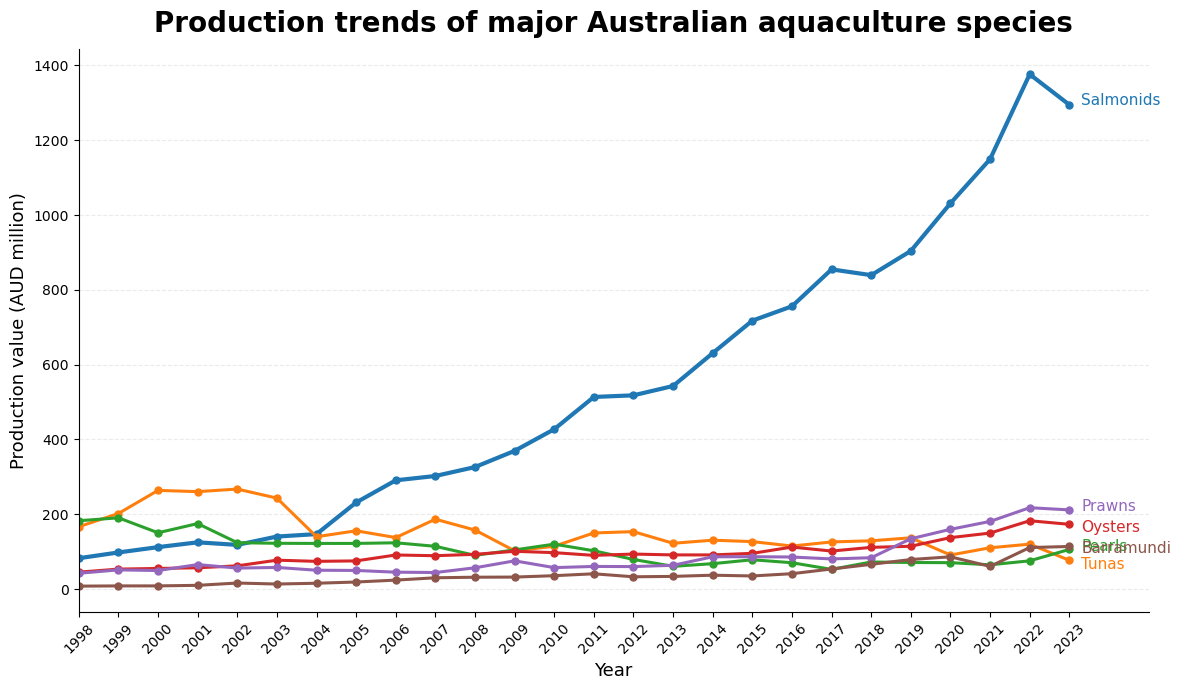

In [14]:
def plot_major_species_trends(df, top_n=6):
    plot_df = df.copy()

    plot_df["year_start"] = plot_df["year"].astype(str).str.extract(r"(\d{4})")[0]
    plot_df["year_start"] = pd.to_numeric(plot_df["year_start"], errors="coerce")
    plot_df = plot_df.dropna(subset=["year_start", "value", "commodity"]).copy()

    top_species = (
        plot_df.groupby("commodity")["value"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    species_trend = plot_df[plot_df["commodity"].isin(top_species)].copy()

    color_map = {
        "Salmonids": "#1f77b4",
        "Tunas": "#ff7f0e",
        "Pearls": "#2ca02c",
        "Oysters": "#d62728",
        "Prawns": "#9467bd",
        "Barramundi": "#8c564b"
    }

    fig, ax = plt.subplots(figsize=(12, 7))

    for species in top_species:
        temp = species_trend[species_trend["commodity"] == species].sort_values("year_start")

        # 這裡一定要用 value / 1000
        y = temp["value"] / 1000

        lw = 3 if species == "Salmonids" else 2.2

        ax.plot(
            temp["year_start"],
            y,
            linewidth=lw,
            marker="o",
            markersize=5,
            color=color_map.get(species, "#333333")
        )

        x_last = temp["year_start"].iloc[-1]
        y_last = y.iloc[-1]

        offset_y = 0
        if species == "Pearls":
            offset_y = 8
        elif species == "Oysters":
            offset_y = -8
        elif species == "Prawns":
            offset_y = 10
        elif species == "Barramundi":
            offset_y = -6
        elif species == "Tunas":
            offset_y = -10
        elif species == "Salmonids":
            offset_y = 12

        ax.text(
            x_last + 0.3,
            y_last + offset_y,
            species,
            fontsize=11,
            color=color_map.get(species, "#333333"),
            va="center"
        )

    ax.set_title(
        "Production trends of major Australian aquaculture species",
        fontsize=20,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("Production value (AUD million)", fontsize=13)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    # 關掉 scientific notation
    ax.ticklabel_format(style="plain", axis="y")

    ax.set_xlim(species_trend["year_start"].min(), species_trend["year_start"].max() + 2)

    plt.xticks(sorted(species_trend["year_start"].unique()), rotation=45)
    plt.tight_layout()
    plt.savefig("../figures/major_species_trends.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_major_species_trends(df_aqua_main, top_n=6)